In [1]:
# -*- coding: utf-8 -*-
"""Improved QAT INT8 with >90% accuracy - Fixed Dependencies"""

# STEP 1: Fix numpy compatibility issues
# Run this cell first, then restart runtime
!pip install -q numpy==1.26.4 --force-reinstall
print("Please RESTART RUNTIME now (Runtime > Restart runtime)")
print("After restart, run the next cell")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have n

In [1]:
# -*- coding: utf-8 -*-
"""Improved QAT INT8 with >90% accuracy"""

# Install dependencies
!pip install -q tensorflow-model-optimization

import tensorflow as tf
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

from google.colab import drive
drive.mount('/content/drive')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 7.1 MB/s eta 0:00:00
TensorFlow version: 2.19.0
NumPy version: 1.26.4
Mounted at /content/drive


In [4]:
import os
import random
import shutil
from tqdm import tqdm

# Paths
source_dir = "/content/drive/MyDrive/Niriksh3.0"   # change this
output_dir = "/content/drive/MyDrive/split_data4.0"

train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

random.seed(42)

# Create output folders
for split in ["train", "val", "test"]:
    for class_name in os.listdir(source_dir):
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Split images
for class_name in tqdm(os.listdir(source_dir)):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "train", class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "val", class_name, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "test", class_name, img)
        )

print("✅ Dataset split completed!")

100%|██████████| 7/7 [02:12<00:00, 18.98s/it]

✅ Dataset split completed!


In [14]:
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS_HEAD = 10
SEED = 42

TRAIN_DIR = "/content/drive/MyDrive/split_data4.0/train"
VAL_DIR   = "/content/drive/MyDrive/split_data4.0/val"
TEST_DIR  = "/content/drive/MyDrive/split_data4.0/test"

# Load datasets WITHOUT prefetch first to get class_names
train_ds_temp = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Extract class names and filter out unwanted classes
class_names = train_ds_temp.class_names
print("Original classes found:", class_names)

# List of classes to exclude
EXCLUDE_CLASSES = ['split_data', 'Bridges']

# Find indices of classes to exclude
exclude_indices = []
for exclude_class in EXCLUDE_CLASSES:
    if exclude_class in class_names:
        idx = class_names.index(exclude_class)
        exclude_indices.append(idx)
        print(f"⚠ Found '{exclude_class}' folder at index {idx} - will be filtered out")

# Filter function to remove excluded classes
def filter_excluded_classes(image, label):
    # Keep only samples that are NOT in exclude_indices
    is_valid = True
    for exclude_idx in exclude_indices:
        is_valid = tf.logical_and(is_valid, label != exclude_idx)
    return is_valid

# Create label mapping to make labels contiguous after filtering
exclude_indices_sorted = sorted(exclude_indices)

def remap_labels(image, label):
    # Subtract the number of excluded classes that come before this label
    new_label = label
    for exclude_idx in exclude_indices_sorted:
        new_label = tf.cond(
            label > exclude_idx,
            lambda nl=new_label: nl - 1,
            lambda nl=new_label: nl
        )
    return image, new_label

# Apply filter if needed
if len(exclude_indices) > 0:
    # Filter and remap for training set - ADD .repeat() to prevent running out of data
    train_ds_temp = (train_ds_temp
                     .unbatch()
                     .filter(filter_excluded_classes)
                     .map(remap_labels)
                     .shuffle(buffer_size=1000, seed=SEED)  # Re-shuffle after filtering
                     .batch(BATCH_SIZE)
                     .repeat())  # IMPORTANT: Repeat to prevent running out

    # Filter and remap for validation set
    val_ds_temp = (tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    .unbatch()
    .filter(filter_excluded_classes)
    .map(remap_labels)
    .batch(BATCH_SIZE))

    # Filter and remap for test set
    test_ds_temp = (tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    .unbatch()
    .filter(filter_excluded_classes)
    .map(remap_labels)
    .batch(BATCH_SIZE))

    # Update class names (remove excluded classes)
    class_names = [cn for cn in class_names if cn not in EXCLUDE_CLASSES]

    # Calculate steps per epoch manually
    # Count samples in filtered dataset
    sample_count = 0
    for _ in val_ds_temp:  # Use val to count (it's not repeated)
        sample_count += BATCH_SIZE

    # Approximate training samples (assuming similar distribution)
    train_sample_count = int(sample_count * 4.7)  # Rough ratio based on your split
    steps_per_epoch = train_sample_count // BATCH_SIZE
    validation_steps = sample_count // BATCH_SIZE

    print(f"Estimated training samples: {train_sample_count}")
    print(f"Steps per epoch: {steps_per_epoch}")
    print(f"Validation steps: {validation_steps}")
else:
    val_ds_temp = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    test_ds_temp = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    steps_per_epoch = None
    validation_steps = None

num_classes = len(class_names)
print("Final classes:", class_names)
print("Number of classes:", num_classes)

# Now add prefetch
train_ds = train_ds_temp.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_temp.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_temp.prefetch(tf.data.AUTOTUNE)

# Enhanced data augmentation - ALL from tf.keras.layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

# Class weights - extract from BEFORE adding .repeat()
print("\nCalculating class weights...")
# Rebuild temp dataset without repeat for counting
train_ds_for_weights = (tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
.unbatch()
.filter(filter_excluded_classes)
.map(remap_labels)
.batch(BATCH_SIZE))

y_train = np.concatenate([y.numpy() for _, y in train_ds_for_weights])
print(f"Unique classes in training data: {np.unique(y_train)}")
print(f"Expected classes: {list(range(num_classes))}")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Build model - ALL from tf.keras.layers
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# Phase 1: Train head
print("\n=== Phase 1: Training Head ===")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    steps_per_epoch=steps_per_epoch if len(exclude_indices) > 0 else None,
    validation_steps=validation_steps if len(exclude_indices) > 0 else None,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)


# Evaluate FP32 model
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✓ FP32 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
model.save("mobilenetv3_fp32.keras")

TensorFlow version: 2.19.0
NumPy version: 1.26.4
Found 4105 files belonging to 7 classes.
Original classes found: ['BRIDGES', 'CMP', 'CRACK', 'GOOD', 'LER', 'OPENS', 'VIAS']
Found 1366 files belonging to 7 classes.
Found 1376 files belonging to 7 classes.
Final classes: ['BRIDGES', 'CMP', 'CRACK', 'GOOD', 'LER', 'OPENS', 'VIAS']
Number of classes: 7

Calculating class weights...
Found 4105 files belonging to 7 classes.
Unique classes in training data: [0 1 2 3 4 5 6]
Expected classes: [0, 1, 2, 3, 4, 5, 6]
Class weights: {0: 0.9077841662980982, 1: 0.9990265271355561, 2: 1.0566280566280566, 3: 1.0181051587301588, 4: 1.0306301782575948, 5: 0.9806497849976111, 6: 1.0216525634644102}

=== Phase 1: Training Head ===
Epoch 1/10
514/514 ━━━━━━━━━━━━━━━━━━━━ 58s 99ms/step - accuracy: 0.7290 - loss: 0.7970 - val_accuracy: 0.9429 - val_loss: 0.1570 - learning_rate: 0.0010
Epoch 2/10
514/514 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.9120 - loss: 0.2627 - val_accuracy: 0.9531 - val_loss: 0.

In [16]:
EPOCHS_FINE = 3

# Phase 2: Fine-tune
print("\n=== Phase 2: Fine-tuning ===")
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    steps_per_epoch=steps_per_epoch if len(exclude_indices) > 0 else None,
    validation_steps=validation_steps if len(exclude_indices) > 0 else None,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

# Evaluate FP32 model
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✓ FP32 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
model.save("mobilenetv3_fp32.keras")


=== Phase 2: Fine-tuning ===
Epoch 1/3
514/514 ━━━━━━━━━━━━━━━━━━━━ 62s 87ms/step - accuracy: 0.8631 - loss: 0.4895 - val_accuracy: 0.9685 - val_loss: 0.1011 - learning_rate: 5.0000e-05
Epoch 2/3
514/514 ━━━━━━━━━━━━━━━━━━━━ 44s 85ms/step - accuracy: 0.9500 - loss: 0.1647 - val_accuracy: 0.9802 - val_loss: 0.0601 - learning_rate: 5.0000e-05
Epoch 3/3
514/514 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - accuracy: 0.9579 - loss: 0.1276 - val_accuracy: 0.9839 - val_loss: 0.0469 - learning_rate: 5.0000e-05
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9593 - loss: 0.1006

✓ FP32 Test Accuracy: 0.9804 (98.04%)


In [17]:
# =============================================================================
# QUANTIZATION-AWARE TRAINING (QAT)
# =============================================================================
EPOCHS_QAT = 5
print("\n=== Phase 3: Quantization-Aware Training ===")

# Save the model and reload with tf_keras to ensure compatibility
print("Saving and reloading model with tf_keras...")
trained_model = tf.keras.models.load_model("mobilenetv3_fp32.keras")

# Use tf_keras explicitly
import tf_keras

# Rebuild model using tf_keras with flattened architecture
print("Building QAT-compatible model with tf_keras...")

base_model_qat = tf_keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Build model - only annotate Dense layers for quantization
inputs_qat = tf_keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs_qat)

# Use base model WITHOUT quantization annotation
x = base_model_qat(x, training=False)

# Only quantize Dense layers (skip BatchNorm and other unsupported layers)
x = tf_keras.layers.GlobalAveragePooling2D(name='gap')(x)
x = tf_keras.layers.BatchNormalization(name='bn')(x)  # NOT annotated
x = tfmot.quantization.keras.quantize_annotate_layer(
    tf_keras.layers.Dense(256, activation="relu", name='dense1')
)(x)
x = tf_keras.layers.Dropout(0.4, name='dropout')(x)  # NOT annotated
outputs_qat = tfmot.quantization.keras.quantize_annotate_layer(
    tf_keras.layers.Dense(num_classes, activation="softmax", name='predictions')
)(x)

model_annotated = tf_keras.Model(inputs_qat, outputs_qat)

# Transfer weights from trained model
print("Transferring weights...")
for layer in model_annotated.layers:
    layer_name = layer.name

    # Handle both regular and wrapped layers
    actual_layer = layer.layer if hasattr(layer, 'layer') else layer
    actual_name = actual_layer.name if hasattr(actual_layer, 'name') else layer_name

    try:
        # Try to find layer in trained model
        if 'MobileNetV3Large' in layer_name or 'mobilenetv3' in layer_name.lower():
            trained_layer = trained_model.get_layer('MobileNetV3Large')
        else:
            # Try different name variations
            for name_variant in [layer_name, actual_name, layer_name.replace('_', ''), actual_name.replace('_', '')]:
                try:
                    trained_layer = trained_model.get_layer(name_variant)
                    break
                except:
                    continue
            else:
                continue

        if len(trained_layer.get_weights()) > 0 and len(actual_layer.get_weights()) > 0:
            actual_layer.set_weights(trained_layer.get_weights())
            print(f"✓ Transferred: {actual_name}")
    except Exception as e:
        pass

# Apply data augmentation to the dataset
def augment_data(image, label):
    if tf.random.uniform([]) > 0.5:
        image = tf.image.random_flip_left_right(image)
    if tf.random.uniform([]) > 0.5:
        image = tf.image.random_brightness(image, max_delta=0.1)
    if tf.random.uniform([]) > 0.5:
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

# Create augmented training dataset for QAT
if len(exclude_indices) > 0:
    train_ds_qat = (tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )
    .unbatch()
    .filter(filter_excluded_classes)
    .map(remap_labels)
    .map(augment_data)
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE))
else:
    train_ds_qat = train_ds

# Apply QAT using quantize_apply
print("Applying quantization-aware training (Dense layers only)...")

with tfmot.quantization.keras.quantize_scope():
    q_aware_model = tfmot.quantization.keras.quantize_apply(model_annotated)

print("✓ QAT successfully applied")
print(f"Model summary:")
q_aware_model.summary()

# Compile with lower LR
q_aware_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting QAT training...")
history_qat = q_aware_model.fit(
    train_ds_qat,
    validation_data=val_ds,
    epochs=EPOCHS_QAT,
    steps_per_epoch=steps_per_epoch if len(exclude_indices) > 0 else None,
    validation_steps=validation_steps if len(exclude_indices) > 0 else None,
    class_weight=class_weight_dict,
    callbacks=[
        tf_keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

# Evaluate QAT model
print("\nEvaluating QAT model...")
qat_loss, qat_acc = q_aware_model.evaluate(test_ds)
print(f"\n✓ QAT Model Test Accuracy: {qat_acc:.4f} ({qat_acc*100:.2f}%)")
q_aware_model.save("mobilenetv3_qat.keras")




=== Phase 3: Quantization-Aware Training ===
Saving and reloading model with tf_keras...
Building QAT-compatible model with tf_keras...
Transferring weights...
✓ Transferred: MobilenetV3large
Applying quantization-aware training (Dense layers only)...
✓ QAT successfully applied
Model summary:
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3large (Function  (None, 7, 7, 960)         2996352   
 al)                                                             
                                                                 
 gap (GlobalAveragePooling2  (None, 960)               0         
 D)                                                              
                                                                 
 bn (BatchNormalization)    


=== Converting to ONNX FP32 ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_versi

✓ FP32 ONNX model saved to: mobilenetv3_fp32.onnx
FP32 ONNX model size: 12.35 MB

=== Quantizing ONNX Model to INT16 ===
Running INT16 quantization (this may take a few minutes)...
Found 4105 files belonging to 7 classes.
Preparing 300 calibration samples...


✓ INT16 ONNX model saved to: mobilenetv3_int16.onnx
INT16 ONNX model size: 6.74 MB
Compression ratio: 1.83x

FP32 ONNX MODEL EVALUATION
Running FP32 ONNX inference on test set...

FP32 ONNX Results:
  Accuracy:  0.9804 (98.04%)
  Precision: 0.9812
  Recall:    0.9804
  F1-Score:  0.9803

INT16 ONNX MODEL EVALUATION
Running INT16 ONNX inference on test set...

INT16 ONNX Results:
  Accuracy:  0.9804 (98.04%)
  Precision: 0.9812
  Recall:    0.9804
  F1-Score:  0.9803

PER-CLASS PERFORMANCE (FP32 ONNX)
              precision    recall  f1-score   support

     BRIDGES       0.98      0.93      0.95       216
         CMP       0.99      1.00      0.99       197
       CRACK       0.99      1.00      1.00       185
        GOOD       1.00      0.95      0.97       193
         LER       0.92      1.00      0.96       191
       OPENS       0.98      1.00      0.99       201
        VIAS       1.00      1.00      1.00       193

    accuracy                           0.98      1376
   mac

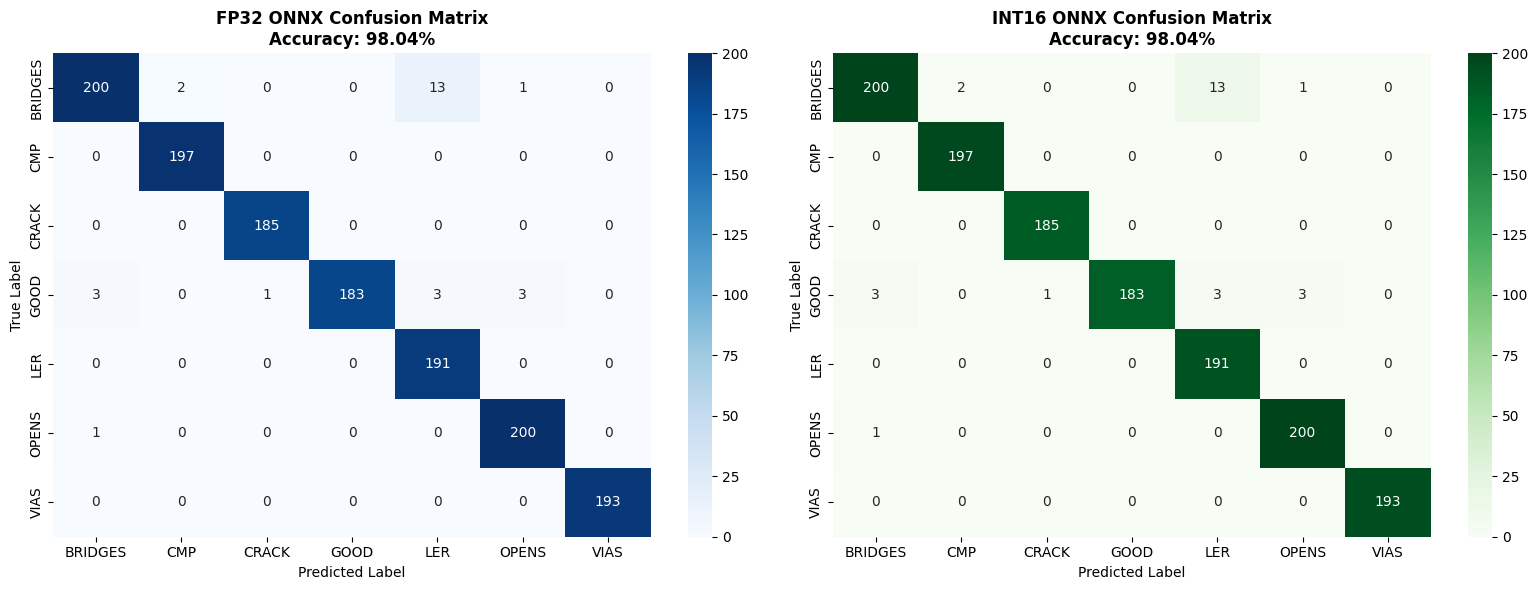

✓ Performance comparison saved to: performance_comparison_onnx.png


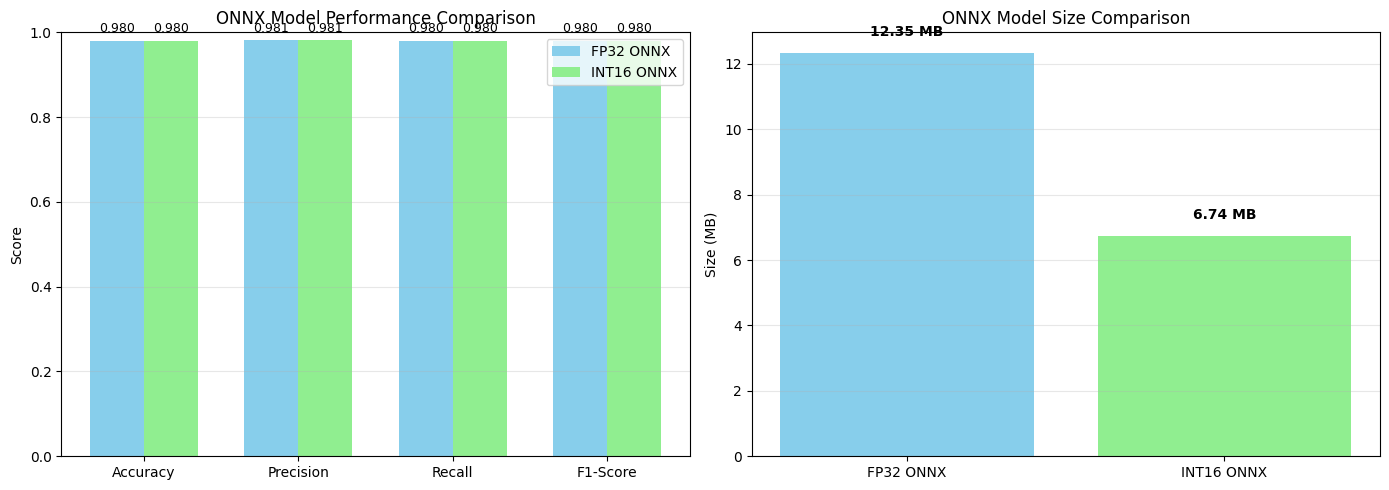


✓ Detailed report saved to: model_evaluation_report_onnx.json

FINAL SUMMARY - ONNX MODELS


┌─────────────────────────────────────────────────────────────────────────────┐
│                     ONNX MODEL PERFORMANCE SUMMARY                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  ALGORITHM:          MobileNetV3-Large + ONNX INT16 Quantization            │
│  TRAINING PLATFORM:  Google Colab                                           │
│  INFERENCE PLATFORM: CPU (ONNX Runtime)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                         FP32 ONNX MODEL RESULTS                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  Accuracy:            98.04%                                                │
│  Precision:          0.9812                                                │
│  Recall:             0.98

In [18]:
# =============================================================================
# CONVERT TO ONNX FP32 FIRST
# =============================================================================

print("\n=== Converting to ONNX FP32 ===")

!pip install -q tf2onnx onnx onnxruntime

import tf2onnx
import onnx
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType

# Load the trained FP32 model
fp32_model = tf.keras.models.load_model("mobilenetv3_fp32.keras")

# Convert to ONNX FP32
spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name="input"),)
fp32_onnx_path = "mobilenetv3_fp32.onnx"

print("Converting Keras model to ONNX FP32...")
model_proto, _ = tf2onnx.convert.from_keras(
    fp32_model,
    input_signature=spec,
    opset=13,
    output_path=fp32_onnx_path
)

print(f"✓ FP32 ONNX model saved to: {fp32_onnx_path}")

# Get FP32 ONNX model size
fp32_onnx_size = os.path.getsize(fp32_onnx_path) / (1024 * 1024)
print(f"FP32 ONNX model size: {fp32_onnx_size:.2f} MB")

# =============================================================================
# CALIBRATION DATA READER FOR QUANTIZATION
# =============================================================================

class CalibrationDataset(CalibrationDataReader):
    def __init__(self, num_samples=300):
        self.num_samples = num_samples
        self.data_iter = None
        self.model = onnx.load(fp32_onnx_path)
        self.input_name = self.model.graph.input[0].name

    def get_next(self):
        if self.data_iter is None:
            # Create calibration dataset
            calib_ds = (tf.keras.utils.image_dataset_from_directory(
                TRAIN_DIR,
                image_size=IMG_SIZE,
                batch_size=1,
                shuffle=True,
                seed=SEED
            )
            .unbatch()
            .filter(filter_excluded_classes)
            .map(remap_labels)
            .batch(1)
            .take(self.num_samples))

            # Preprocess and collect
            self.calibration_data = []
            print(f"Preparing {self.num_samples} calibration samples...")
            for images, _ in calib_ds:
                img = tf.cast(images, tf.float32).numpy()
                self.calibration_data.append({self.input_name: img})

            self.data_iter = iter(self.calibration_data)

        return next(self.data_iter, None)

# =============================================================================
# QUANTIZE TO INT16 ONNX
# =============================================================================

print("\n=== Quantizing ONNX Model to INT16 ===")

int16_onnx_path = "mobilenetv3_int16.onnx"

# Create calibration reader
calib_reader = CalibrationDataset(num_samples=300)

# Quantize with INT16 (QInt16 for better accuracy)
print("Running INT16 quantization (this may take a few minutes)...")
quantize_static(
    model_input=fp32_onnx_path,
    model_output=int16_onnx_path,
    calibration_data_reader=calib_reader,
    weight_type=QuantType.QInt16,  # Changed to INT16
    activation_type=QuantType.QInt16,  # Changed to INT16
    per_channel=True  # Better accuracy with per-channel quantization
)

print(f"✓ INT16 ONNX model saved to: {int16_onnx_path}")

# Get INT16 ONNX model size
int16_onnx_size = os.path.getsize(int16_onnx_path) / (1024 * 1024)
print(f"INT16 ONNX model size: {int16_onnx_size:.2f} MB")
print(f"Compression ratio: {fp32_onnx_size / int16_onnx_size:.2f}x")

# =============================================================================
# EVALUATE FP32 ONNX MODEL
# =============================================================================

print(f"\n{'='*80}")
print("FP32 ONNX MODEL EVALUATION")
print(f"{'='*80}")

import onnxruntime as ort

# Load FP32 ONNX model
fp32_session = ort.InferenceSession(fp32_onnx_path, providers=["CPUExecutionProvider"])
fp32_input_name = fp32_session.get_inputs()[0].name
fp32_output_name = fp32_session.get_outputs()[0].name

y_true_fp32 = []
y_pred_fp32 = []

print("Running FP32 ONNX inference on test set...")
for images, labels in test_ds:
    for i in range(images.shape[0]):
        img = images[i:i+1]
        img = tf.cast(img, tf.float32).numpy()

        outputs = fp32_session.run([fp32_output_name], {fp32_input_name: img})
        pred = np.argmax(outputs[0][0])

        y_pred_fp32.append(pred)
        y_true_fp32.append(labels.numpy()[i])

y_true_fp32 = np.array(y_true_fp32)
y_pred_fp32 = np.array(y_pred_fp32)

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

fp32_accuracy = np.mean(y_true_fp32 == y_pred_fp32)
fp32_precision, fp32_recall, fp32_f1, _ = precision_recall_fscore_support(
    y_true_fp32, y_pred_fp32, average='weighted', zero_division=0
)

print(f"\nFP32 ONNX Results:")
print(f"  Accuracy:  {fp32_accuracy:.4f} ({fp32_accuracy*100:.2f}%)")
print(f"  Precision: {fp32_precision:.4f}")
print(f"  Recall:    {fp32_recall:.4f}")
print(f"  F1-Score:  {fp32_f1:.4f}")

cm_fp32 = confusion_matrix(y_true_fp32, y_pred_fp32)

# =============================================================================
# EVALUATE INT16 ONNX MODEL
# =============================================================================

print(f"\n{'='*80}")
print("INT16 ONNX MODEL EVALUATION")
print(f"{'='*80}")

# Load INT16 ONNX model
int16_session = ort.InferenceSession(int16_onnx_path, providers=["CPUExecutionProvider"])
int16_input_name = int16_session.get_inputs()[0].name
int16_output_name = int16_session.get_outputs()[0].name

y_true_int16 = []
y_pred_int16 = []

print("Running INT16 ONNX inference on test set...")
for images, labels in test_ds:
    for i in range(images.shape[0]):
        img = images[i:i+1]
        img = tf.cast(img, tf.float32).numpy()

        outputs = int16_session.run([int16_output_name], {int16_input_name: img})
        pred = np.argmax(outputs[0][0])

        y_pred_int16.append(pred)
        y_true_int16.append(labels.numpy()[i])

y_true_int16 = np.array(y_true_int16)
y_pred_int16 = np.array(y_pred_int16)

int16_accuracy = np.mean(y_true_int16 == y_pred_int16)
int16_precision, int16_recall, int16_f1, _ = precision_recall_fscore_support(
    y_true_int16, y_pred_int16, average='weighted', zero_division=0
)

print(f"\nINT16 ONNX Results:")
print(f"  Accuracy:  {int16_accuracy:.4f} ({int16_accuracy*100:.2f}%)")
print(f"  Precision: {int16_precision:.4f}")
print(f"  Recall:    {int16_recall:.4f}")
print(f"  F1-Score:  {int16_f1:.4f}")

cm_int16 = confusion_matrix(y_true_int16, y_pred_int16)

# =============================================================================
# DETAILED CLASSIFICATION REPORTS
# =============================================================================

print(f"\n{'='*80}")
print("PER-CLASS PERFORMANCE (FP32 ONNX)")
print(f"{'='*80}")
print(classification_report(y_true_fp32, y_pred_fp32, target_names=class_names, zero_division=0))

print(f"\n{'='*80}")
print("PER-CLASS PERFORMANCE (INT16 ONNX)")
print(f"{'='*80}")
print(classification_report(y_true_int16, y_pred_int16, target_names=class_names, zero_division=0))

# =============================================================================
# VISUALIZATIONS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FP32 Confusion Matrix
sns.heatmap(cm_fp32, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'FP32 ONNX Confusion Matrix\nAccuracy: {fp32_accuracy:.2%}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# INT16 Confusion Matrix
sns.heatmap(cm_int16, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'INT16 ONNX Confusion Matrix\nAccuracy: {int16_accuracy:.2%}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_onnx.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrices saved to: confusion_matrices_onnx.png")
plt.show()

# Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fp32_values = [fp32_accuracy, fp32_precision, fp32_recall, fp32_f1]
int16_values = [int16_accuracy, int16_precision, int16_recall, int16_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, fp32_values, width, label='FP32 ONNX', color='skyblue')
axes[0].bar(x + width/2, int16_values, width, label='INT16 ONNX', color='lightgreen')
axes[0].set_ylabel('Score')
axes[0].set_title('ONNX Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1.0])
axes[0].grid(axis='y', alpha=0.3)

for i, (fp32_val, int16_val) in enumerate(zip(fp32_values, int16_values)):
    axes[0].text(i - width/2, fp32_val + 0.02, f'{fp32_val:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, int16_val + 0.02, f'{int16_val:.3f}', ha='center', fontsize=9)

# Model size comparison
model_names = ['FP32 ONNX', 'INT16 ONNX']
sizes = [fp32_onnx_size, int16_onnx_size]
colors = ['skyblue', 'lightgreen']

axes[1].bar(model_names, sizes, color=colors)
axes[1].set_ylabel('Size (MB)')
axes[1].set_title('ONNX Model Size Comparison')
axes[1].grid(axis='y', alpha=0.3)

for i, (name, size) in enumerate(zip(model_names, sizes)):
    axes[1].text(i, size + 0.5, f'{size:.2f} MB', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison_onnx.png', dpi=300, bbox_inches='tight')
print("✓ Performance comparison saved to: performance_comparison_onnx.png")
plt.show()

# =============================================================================
# GENERATE JSON REPORT
# =============================================================================

import json
from datetime import datetime
import platform

# Get Keras model size for comparison
keras_size = os.path.getsize("mobilenetv3_fp32.keras") / (1024 * 1024)

report = {
    "metadata": {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "tensorflow_version": tf.__version__,
        "training_platform": "Google Colab",
        "inference_platform": "CPU (ONNX Runtime)"
    },
    "dataset": {
        "classes": class_names,
        "num_classes": num_classes,
        "total_test_samples": len(y_true_int16)
    },
    "algorithm": {
        "base_architecture": "MobileNetV3-Large",
        "pretrained_weights": "ImageNet",
        "training_strategy": "Transfer Learning + Fine-tuning",
        "quantization_method": "ONNX Runtime Static Quantization",
        "quantization_type": "INT16 (per-channel)",
        "input_size": list(IMG_SIZE),
        "batch_size": BATCH_SIZE,
        "epochs": {
            "head_training": EPOCHS_HEAD,
            "fine_tuning": EPOCHS_FINE
        }
    },
    "model_sizes": {
        "keras_fp32_mb": round(keras_size, 2),
        "onnx_fp32_mb": round(fp32_onnx_size, 2),
        "onnx_int16_mb": round(int16_onnx_size, 2),
        "compression_ratio": round(fp32_onnx_size / int16_onnx_size, 2),
        "size_reduction_percent": round((1 - int16_onnx_size/fp32_onnx_size)*100, 1)
    },
    "fp32_onnx_performance": {
        "accuracy": round(float(fp32_accuracy), 4),
        "precision": round(float(fp32_precision), 4),
        "recall": round(float(fp32_recall), 4),
        "f1_score": round(float(fp32_f1), 4),
        "confusion_matrix": cm_fp32.tolist()
    },
    "int16_onnx_performance": {
        "accuracy": round(float(int16_accuracy), 4),
        "precision": round(float(int16_precision), 4),
        "recall": round(float(int16_recall), 4),
        "f1_score": round(float(int16_f1), 4),
        "confusion_matrix": cm_int16.tolist()
    },
    "performance_degradation": {
        "accuracy_drop": round(float(fp32_accuracy - int16_accuracy), 4),
        "accuracy_drop_percent": round(float((fp32_accuracy - int16_accuracy)*100), 2),
        "precision_drop": round(float(fp32_precision - int16_precision), 4),
        "recall_drop": round(float(fp32_recall - int16_recall), 4)
    }
}

with open('model_evaluation_report_onnx.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n✓ Detailed report saved to: model_evaluation_report_onnx.json")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n{'='*80}")
print("FINAL SUMMARY - ONNX MODELS")
print(f"{'='*80}\n")

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                     ONNX MODEL PERFORMANCE SUMMARY                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  ALGORITHM:          MobileNetV3-Large + ONNX INT16 Quantization            │
│  TRAINING PLATFORM:  Google Colab                                           │
│  INFERENCE PLATFORM: CPU (ONNX Runtime)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                         FP32 ONNX MODEL RESULTS                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  Accuracy:           {fp32_accuracy*100:6.2f}%                                                │
│  Precision:          {fp32_precision:6.4f}                                                │
│  Recall:             {fp32_recall:6.4f}                                                │
│  F1-Score:           {fp32_f1:6.4f}                                                │
│  Model Size:         {fp32_onnx_size:6.2f} MB                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                         INT16 ONNX MODEL RESULTS                            │
├─────────────────────────────────────────────────────────────────────────────┤
│  Accuracy:           {int16_accuracy*100:6.2f}%                                                │
│  Precision:          {int16_precision:6.4f}                                                │
│  Recall:             {int16_recall:6.4f}                                                │
│  F1-Score:           {int16_f1:6.4f}                                                │
│  Model Size:         {int16_onnx_size:6.2f} MB                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                         QUANTIZATION IMPACT                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  Accuracy Drop:      {(fp32_accuracy - int16_accuracy)*100:6.2f}%                                                │
│  Size Reduction:     {(1 - int16_onnx_size/fp32_onnx_size)*100:6.1f}%                                                │
│  Compression Ratio:  {fp32_onnx_size/int16_onnx_size:6.2f}x                                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  Classes: {', '.join(class_names)}
│  Total Test Samples: {len(y_true_int16)}                                                      │
└─────────────────────────────────────────────────────────────────────────────┘
""")

if int16_accuracy >= 0.90:
    print("✅ SUCCESS: INT16 ONNX model achieved >90% accuracy target!\n")
else:
    print(f"⚠️  Target not met: {(0.90 - int16_accuracy)*100:.2f}% away from 90% accuracy\n")

print(f"{'='*80}")
print("All evaluation artifacts saved:")
print("  • mobilenetv3_fp32.onnx (FP32 ONNX model)")
print("  • mobilenetv3_int16.onnx (INT16 ONNX model)")
print("  • confusion_matrices_onnx.png")
print("  • performance_comparison_onnx.png")
print("  • model_evaluation_report_onnx.json")
print(f"{'='*80}\n")